# Cross Validation(CV)


- Cross Validation is a technique used in machine learning to : 
    - Test how well the model will perform on unseen data. 
    - Avoid Overfitting. 
#### Why do we use it ? 
    - We use CV when we train and test model on the same data - it might look perfect (as model has seen the data before).
    - CV helps to simulate real word performance. 
#### How Does it Work? 
     - Split the data into K equal parts. 
     - Use k-1 parts for training, and 1 part for testing. 
     - Repeat this K times, each time using a different part for testing. 

In [43]:
# load libraries
# standard libraries & graph setting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style("whitegrid")
# sklearn librabries for linear regression
from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.metrics import mean_squared_error as MSE
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RepeatedKFold
from sklearn.feature_selection import RFE, RFECV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
# sklearn librabries for logistic regression
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, auc
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold, RepeatedKFold
from sklearn.feature_selection import RFE, RFECV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures# slearn pipeline
from sklearn.pipeline import make_pipeline


# Example 2: Boston House Price 

**Data Set Characteristics:**  

---
    :Number of Instances: 506 

    :Number of Attributes: 13 numeric/categorical predictive. Median Value (attribute 14) is usually the target.

    :Attribute Information (in order):
        - CRIM     per capita crime rate by town
        - ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
        - INDUS    proportion of non-retail business acres per town
        - CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
        - NOX      nitric oxides concentration (parts per 10 million)
        - RM       average number of rooms per dwelling
        - AGE      proportion of owner-occupied units built prior to 1940
        - DIS      weighted distances to five Boston employment centres
        - RAD      index of accessibility to radial highways
        - TAX      full-value property-tax rate per 10,000 USD
        - PTRATIO  pupil-teacher ratio by town
        - B        1000(Bk - 0.63)^2 where Bk is the proportion of black people by town
        - LSTAT    % lower status of the population
        - MEDV     Median value of owner-occupied homes in 1000's USD

    :Missing Attribute Values: None

    :Creator: Harrison, D. and Rubinfeld, D.L.

---

This is a copy of UCI ML housing dataset.
https://archive.ics.uci.edu/ml/machine-learning-databases/housing/

* Part 1: Train & Test Split and Regressions
* Part 2: Introducing K-fold Cross Validation (CV)
* Part 3: K-fold CV applications

In [20]:
import os

# Get current working directory
cwd = os.getcwd()

print("Current Working Directory:", cwd)
# Define the new path you want to change to
new_path = "C:/Users/vansh/Downloads" 

# Change the working directory
os.chdir(new_path)



Current Working Directory: C:\Users\vansh\Downloads


In [22]:
# Load the Data Set 
h=pd.read_csv("boston.csv")
h.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    float64
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    float64
 9   tax      506 non-null    float64
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  price    506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


In [27]:
# Define X and  Y 
X,y = h.drop("price",axis=1),h["price"]


In [33]:
# Split the data into training and test 
# Split train & test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=101) 

In [37]:
X_train.shape


(430, 13)

In [39]:
X_test.shape

(76, 13)

In [45]:
# Using train set for modelling and test set for evaluating
LR = LinearRegression()
LR.fit(X_train,y_train)
pd.DataFrame(LR.coef_.round(3),index =X.columns).T

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
0,-0.111,0.037,0.032,2.91,-15.086,4.183,-0.002,-1.383,0.263,-0.011,-0.951,0.008,-0.522


– Quick Insights
crim: Negative → Higher crime rate lowers house price

rm: Positive → More rooms increase house price

nox: Strong negative → Pollution decreases house price

dis: Negative → Farther distance reduces price

lstat: Negative → More lower-status population → lower price

ptratio: Negative → Higher pupil-teacher ratio reduces price

Positive = price goes up
Negative = price goes down



In [54]:
# MSE train 
yp1=LR.predict(X_train)
print("MSE(train) =", MSE(y_train,yp1).round(3))
# MSE test
yp2=LR.predict(X_test)
print("MSE(test) =", MSE(y_test,yp2).round(3))


MSE(train) = 19.672
MSE(test) = 35.482


In [58]:
# The model Performs better on training data. 
# As when the difference in MSE test is larger there is a sign of OverFitting


In [62]:
# MSE test with different Split 
X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.15, random_state=99) 
LR.fit(X_train1,y_train1)
print("MSE(train) =", MSE(y_train1, LR.predict(X_train1)).round(3))
print("MSE(test) =", MSE(y_test1, LR.predict(X_test1)).round(3))



MSE(train) = 21.381
MSE(test) = 26.249


In [64]:
# Lets Try Applying Lasso and see the differece

In [66]:
# Before Lasso we need to scale 
scaler= StandardScaler()
X_train_Std=scaler.fit_transform(X_train)
X_test_Std=scaler.fit_transform(X_test)
lasso=Lasso(alpha=1).fit(X_train_Std,y_train)
pd.DataFrame(lasso.coef_,index=X.columns).T.round(5)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
0,-0.0,0.0,-0.0,0.09243,-0.0,2.7434,-0.0,-0.0,-0.0,-0.0,-1.33672,0.05943,-3.44136


In [72]:
lasso1=Lasso(alpha=0.1).fit(X_train_Std, y_train)
pd.DataFrame(lasso1.coef_, index = X.columns).T.round(5)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
0,-0.66774,0.44336,-0.0,0.69391,-1.24398,2.9675,-0.0,-2.15384,0.8478,-0.66673,-1.90517,0.65167,-3.64384


In [82]:
yp1=lasso.predict(X_test_Std)
yp2=lasso1.predict(X_test_Std)
print("MSE =", MSE(y_test, yp1).round(3))
print("MSE =", MSE(y_test, yp2).round(3))

MSE = 47.046
MSE = 38.459


**Notes**

* Lasso with alpha=1 is a bit harsh (only 4 features survive, alpha=0.1 better?
* Apprantly, LR outperforms LASSO (in both cases)
* Other alpha values? (alpha: hyperparameter)
* Only one random split -- can the outcomes be sensitive to how the data is splitted?

# K fold Cross Validation 
* Here comes CV to save

In [86]:
# prepare the cross-validation procedure 
# set K (n_splits)=10 so that 90-10% split (train/test)
# shuffle=True: shuffle the data randomly -- set random_state=101 (for shuffle)
# modelling outcomes differ when a different random_state is considered
cv10 = KFold(n_splits=10, random_state=101, shuffle=True)
cv10

KFold(n_splits=10, random_state=101, shuffle=True)

**Notes**

* set K (n_splits)=10 --> partition the data into 10 folds
* use 9 folds for training & the remaining 1 to test --> so, 10 evaluations
* shuffle=True & random_state=101 (shuffling first, then partition), for repetition

In [97]:
LR = LinearRegression()
scores = cross_val_score(LR, X, y, scoring='neg_mean_squared_error', cv=cv10)
mse1=pd.DataFrame(-scores,columns=["LR"])
mse1.round(3).T

,0,1,2,3,4,5,6,7,8,9
LR,34.783,36.839,19.864,27.33,39.34,8.375,23.913,12.474,18.672,23.116


In [99]:
mse1.describe().T

,count,mean,std,min,25%,50%,75%,max
LR,10.0,24.470592,10.266311,8.375444,18.969838,23.514341,32.920041,39.340136


**Notes**

* MSE varies over the 10 partitions (8.375 to 36.839), with mean about 24 & std 10.

In [102]:
# Repeat the K fold several times 
rcv=RepeatedKFold(n_splits=10,n_repeats=3,random_state=101)
rcv

RepeatedKFold(n_repeats=3, n_splits=10, random_state=101)

In [118]:
# LR
scores = cross_val_score(LR, X, y, scoring='neg_mean_squared_error', cv=rcv)
mse1a=pd.DataFrame(-scores,columns=["LR"])
mse1a.round(3).T

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
LR,34.783,36.839,19.864,27.33,39.34,8.375,23.913,12.474,18.672,23.116,...,27.357,26.713,11.181,42.604,38.492,17.756,23.885,15.858,13.987,17.874


In [120]:
# The Problem is we cant scale before splitting due to data leaks. 
# Therefore we have to use make_pipeline
# To make each fold in cross validation has its own scaling, done only on thr training dataset which is unseen by test dataset. 


In [122]:
from sklearn.pipeline import make_pipeline
# make_pipeline
pipe_lasso = make_pipeline(StandardScaler(), Lasso(alpha=0.1))
scores = cross_val_score(pipe_lasso, X, y, scoring='neg_mean_squared_error', cv=cv10)
mse2=pd.DataFrame(-scores, columns=['Lasso'])
mse2.round(3).T

,0,1,2,3,4,5,6,7,8,9
Lasso,36.246,38.218,19.966,27.398,40.752,8.156,20.673,11.886,21.374,22.78


In [128]:
mse2.describe().T

,count,mean,std,min,25%,50%,75%,max
Lasso,10.0,24.744876,10.915168,8.15595,20.142323,22.077152,34.033883,40.752332


<Axes: >

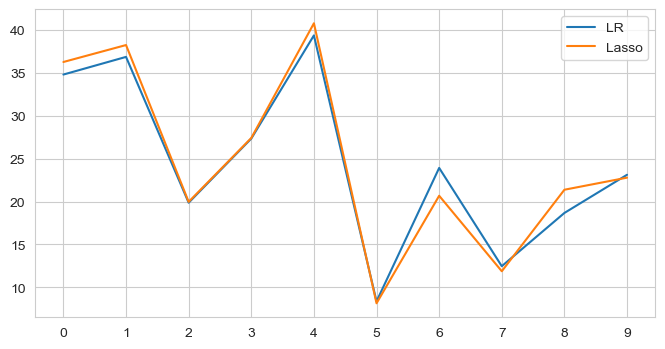

In [134]:
# Line chart to see two sets of MSE
mse=pd.concat([mse1,mse2],axis=1)
mse.plot(kind="line",figsize=(8,4),xticks=range(10))

In [138]:
from sklearn.pipeline import make_pipeline
# make_pipeline
pipe_lasso1 = make_pipeline(StandardScaler(), Lasso(alpha=1))
scores = cross_val_score(pipe_lasso1, X, y, scoring='neg_mean_squared_error', cv=cv10)
mse3=pd.DataFrame(-scores, columns=['Lasso'])
mse3.round(3).T

,0,1,2,3,4,5,6,7,8,9
Lasso,49.037,39.381,27.9,35.25,45.093,11.211,22.415,16.515,28.196,25.096


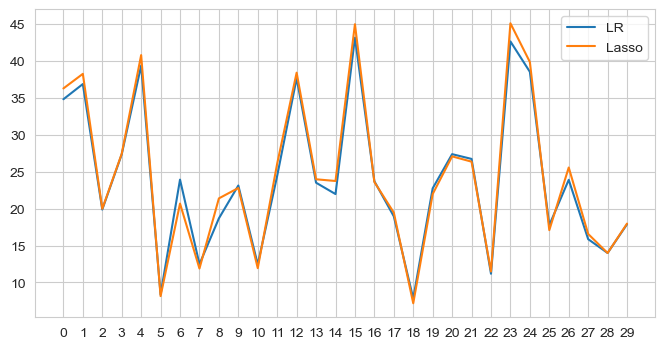

In [142]:
scores = cross_val_score(pipe_lasso, X, y, scoring='neg_mean_squared_error', cv=rcv)
mse2a=pd.DataFrame(-scores, columns=['Lasso'])
# line chart on two sets of mse's
mse=pd.concat([mse1a,mse2a], axis=1)
mse.plot(kind='line', figsize=(8,4), xticks=range(30));

### Cross-Validation Comparison: Linear vs. Lasso Regression

To evaluate model performance, we conducted k-fold cross-validation using two approaches:
1. **10-fold CV** with fixed random state (cv10)
2. **Repeated CV** over 30 evaluations (rcv)

In both cases, we compared the Mean Squared Error (MSE) of **Linear Regression** and **Lasso Regression (α = 0.1)**.

From the first chart (10 folds), Lasso showed slightly lower MSE in several folds, indicating better generalization in those splits.

The second chart (30 folds) provided a more stable comparison, showing that **Lasso consistently achieved similar or lower MSE** than Linear Regression across most folds. This demonstrates that regularization in Lasso helps control overfitting and improves prediction consistency.

### 🏁 Final Verdict:
**Lasso Regression performed slightly better overall**, especially in the 30-fold setup, by offering lower error and more stable predictions.


In [147]:
# Using K fold CV for tuning hyperparameters
# Finding the best optimal alpha 
lasso_cv=LassoCV(cv=10)
pipe_lasso=make_pipeline(StandardScaler(),lasso_cv)
pipe_lasso.fit(X_train,y_train)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('lassocv', LassoCV(cv=10))])

In [149]:
# Lasso CV automatically searches for the best alpha and tests multiple alpha values and picks that one that gives the Lowest MSE
print("penalty parameter: ", lasso_cv.alpha_)
pd.DataFrame(lasso_cv.coef_,index=X.columns).T


penalty parameter:  0.03809825296384828


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
0,-0.845108,0.67015,0.0,0.707911,-1.51847,2.864973,-0.0,-2.60682,1.692657,-1.339991,-1.986692,0.71304,-3.65405


In [153]:
# Alpha Values of 0.038 is selected and parameters indus and age are out (turned to 0)
lasso_cv.alphas_

array([6.6577779 , 6.20906596, 5.79059569, 5.40032892, 5.03636483,
       4.69693069, 4.38037329, 4.08515079, 3.8098253 , 3.55305582,
       3.31359175, 3.09026676, 2.88199312, 2.68775643, 2.50661064,
       2.33767347, 2.18012211, 2.03318917, 1.89615903, 1.76836426,
       1.64918242, 1.53803305, 1.43437477, 1.33770271, 1.24754602,
       1.1634656 , 1.08505191, 1.01192304, 0.94372282, 0.88011906,
       0.82080198, 0.76548267, 0.7138917 , 0.66577779, 0.6209066 ,
       0.57905957, 0.54003289, 0.50363648, 0.46969307, 0.43803733,
       0.40851508, 0.38098253, 0.35530558, 0.33135918, 0.30902668,
       0.28819931, 0.26877564, 0.25066106, 0.23376735, 0.21801221,
       0.20331892, 0.1896159 , 0.17683643, 0.16491824, 0.1538033 ,
       0.14343748, 0.13377027, 0.1247546 , 0.11634656, 0.10850519,
       0.1011923 , 0.09437228, 0.08801191, 0.0820802 , 0.07654827,
       0.07138917, 0.06657778, 0.06209066, 0.05790596, 0.05400329,
       0.05036365, 0.04696931, 0.04380373, 0.04085151, 0.03809

# The associated MSE for Each Fold 
lasso_cv.mse_path_

In [157]:
# Now measure how well the final model has generalised the unseen data 
# MSE (evaluation on the test set)
yp3=pipe_lasso.predict(X_test)
print("MSE =", MSE(y_test, yp3).round(3))


MSE = 36.059


The final Lasso model, tuned using 10-fold cross-validation, achieved a Mean Squared Error (MSE) of **36.059** on the test set. This suggests that the model generalizes reasonably well to unseen data. The use of `LassoCV` allowed automatic selection of the regularization parameter (`alpha`), helping balance model complexity and prediction accuracy.


# Recursive Feature Elimination with Cross Validation (RFECV)


#### RFECV is a feature selection technique that :
* Recursively removes the least important features 
* Uses k Fold cross validation to evaluate model performance
* Automatically determines the optimal number of features to keep 


In [167]:
rfe_cv=RFECV(LinearRegression(),cv=10,scoring='neg_mean_squared_error')
pipe_rfe=make_pipeline(StandardScaler(),rfe_cv)
pipe_rfe.fit(X_train,y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('rfecv',
                 RFECV(cv=10, estimator=LinearRegression(),
                       scoring='neg_mean_squared_error'))])

In [169]:
rfe_cv.n_features_

12

In [171]:
pd.DataFrame(rfe_cv.ranking_,index=X.columns).T

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
0,1,1,1,1,1,1,2,1,1,1,1,1,1


In [173]:
# get the Feature selected (Age is excluded to high ranking)
features=X_train.columns[rfe_cv.support_]
features

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat'],
      dtype='object')

In [179]:
X_train[features].head()

,crim,zn,indus,chas,nox,rm,dis,rad,tax,ptratio,b,lstat
161,1.46336,0.0,19.58,0.0,0.605,7.489,1.9709,5.0,403.0,14.7,374.43,1.73
48,0.25387,0.0,6.91,0.0,0.448,5.399,5.8700,3.0,233.0,17.9,396.90,30.81
308,0.49298,0.0,9.90,0.0,0.544,6.635,3.3175,4.0,304.0,18.4,396.90,4.54
401,14.23620,0.0,18.10,0.0,0.693,6.343,1.5741,24.0,666.0,20.2,396.90,20.32
24,0.75026,0.0,8.14,0.0,0.538,5.924,4.3996,4.0,307.0,21.0,394.33,16.30


In [181]:
X_train_12=X_train[features]
X_test_12=X_test[features]

In [185]:
# Re run the regression with 12 Features
LR.fit(X_train_12,y_train)
print("MSE =", MSE(y_test,LR.predict(X_test_12)).round(3))

MSE = 35.47
